# Milestone 1 — EDA

In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
pd.set_option("display.max_colwidth", 200)

In [2]:
# load train and test
data_dir = Path("../data")
train = pd.read_csv(data_dir / "train.csv")
test = pd.read_csv(data_dir / "test.csv")

In [3]:
# shapes and head
print(train.shape, test.shape)
train.head()

(2000, 8) (500, 7)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.,Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a histo...,"Martin Heidegger believes that humans do not exist inside time, but that they are time. The relationship to the past is a present awareness of having been, and the relationship to the future invol...","Martin Heidegger does not believe in the existence of time or that it has any effect on human consciousness. The relationship to the past and the future is insignificant, and human existence is so...",Martin Heidegger believes that the relationship between time and human existence is cyclical. The past and present are interconnected and the future is predetermined. Human beings do not have free...,"Martin Heidegger believes that time is an illusion, and the past, present, and future are all happening simultaneously. Humans exist outside of this illusion and are guided by a higher power.",B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fusion reactions. This method is relatively ea...,Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce heavy-ion fusion reactions. This method is relatively di...,Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fusion reactions. This method is relatively di...,Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce heavy-ion fusion reactions. This method is relatively ea...,Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fission reactions. This method is relatively e...,A
2,3,Determine the correct option: What is the term used in astrophysics to describe light-matter interactions resulting in energy shifts in the radiation field? among the listed options.,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Martin Heidegger's view on the relationship between time and human existence? carefully.,Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a histo...,"Martin Heidegger believes that humans do not exist inside time, but that they are time. The relationship to the past is a present awareness of having been, and the relationship to the future invol...","Martin Heidegger does not believe in the existence of time or that it has any effect on human consciousness. The relationship to the past and the future is insignificant, and human existence is so...",Martin Heidegger believes that the relationship between time and human existence is cyclical. The past and present are interconnected and the future is predetermined. Human beings do not have free...,"Martin Heidegger believes that time is an illusion, and the past, present, and future are all happening simultaneously. Humans exist outside of this illusion and are guided by a higher power.",B
4,5,"Identify the correct statement: What is the concept of simultaneity in Einstein's book, Relativity? carefully.","Simultaneity is relative, meaning that two events that appear simultaneous to an observer in a particular inertial reference frame need not be judged as simultaneous by a second observer in a diff...","Simultaneity is relative, meaning that two events that appear simultaneous to

In [4]:
# train answer label distribution
train["answer"].value_counts(normalize=True).round(4)

answer
B    0.2450
C    0.2295
A    0.1845
D    0.1790
E    0.1620
Name: proportion, dtype: float64

count    2000.00
mean      117.67
std        44.41
min        19.00
25%        87.75
50%       111.00
75%       141.00
max       337.00
Name: prompt, dtype: float64


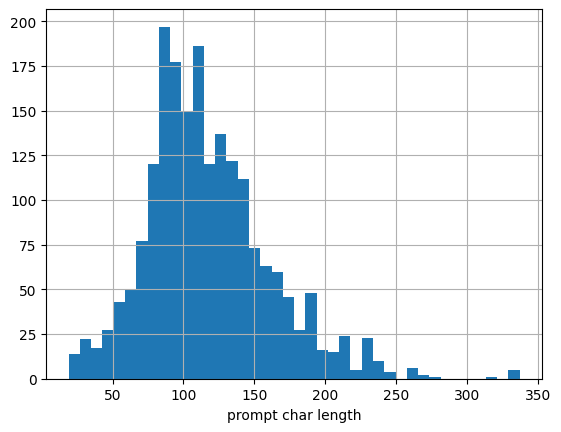

In [5]:
# prompt length distribution
print(train["prompt"].str.len().describe().round(2))
train["prompt"].str.len().hist(bins=40)
plt.xlabel("prompt char length")
plt.show()

In [6]:
# option length distribution per column
opt_cols = ["A", "B", "C", "D", "E"]
opt_lens = pd.DataFrame({c: train[c].str.len() for c in opt_cols})
opt_lens.describe().round(2)

,A,B,C,D,E
count,2000.00,2000.00,2000.00,2000.00,2000.00
mean,164.09,166.62,167.23,162.56,164.23
std,105.68,113.83,105.72,104.12,107.78
min,1.00,2.00,2.00,1.00,2.00
25%,86.00,82.00,88.00,91.00,84.00
50%,143.00,151.00,158.00,141.00,144.00
75%,234.00,222.00,224.00,231.00,224.00
max,472.00,662.00,530.00,450.00,587.00


In [7]:
# longest option inspection
flat = opt_lens.stack()
top_idx = flat.idxmax()
print(top_idx, int(flat.max()))
print(train.loc[top_idx[0], top_idx[1]])

(176, 'B') 662
The Milky Way galaxy has a supermassive black hole at its center because the star S14 follows an elliptical orbit with a period of 15.2 years and a pericenter of 17 light-hours from the center of the central object. From the motion of star S14, the object's mass can be estimated as 4.0 million M☉, or about 7.96×1036 kg. The radius of the central object must be less than 17 light-hours, because otherwise S14 would collide with it. Observations of the star S2 indicate that the radius is no more than 6.25 light-hours, about the diameter of Uranus' orbit. No known astronomical object other than a black hole can contain 4.0 million M☉ in this volume of space.
